#### Clusters Analysis usando o algoritmo k-means  

#### Objetivo: 
        Separar um conjunto de objetos/clientes em grupos (clusters) de forma que os membros de qualquer grupo formado 
        sejam os mais homogêneos possíveis com relação a algum critério, como por exemplo a distância euclidiana.



#### Procedimento:

#### (1) Selecionar  somente variáveis quantitativas (p).
#### (2) Análise exploratória dos dados. 
#### (3) Avaliar a presença de outliers e pontos extremos. 
#### (4) Padronizar as variáveis antes de se calcular as distâncias, assim, as "p" variáveis serão igualmente importantes. 
         Geralmente, a padronização feita é para que todas as variáveis (quantitativas) tenham média zero e variância 1.





In [500]:
# Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from collections import Counter


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [501]:
# Importar a base de dados Recência, Frequência e Valor (RFV)
BaseRFV = pd.read_csv(r'Base_RFV.csv',sep=',')

In [502]:
BaseRFV.head()

,id_cliente,compras,recencia,valor
0,1,4,4.9,172.37
1,2,2,11.0,172.37
2,3,4,4.7,157.17
3,4,1,10.2,158.14
4,5,3,8.9,172.61


In [503]:
BaseRFV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9878 entries, 0 to 9877
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  9878 non-null   int64  
 1   compras     9878 non-null   int64  
 2   recencia    9878 non-null   float64
 3   valor       9878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 308.8 KB


## Análise exploratória dos dados

- Utilize o Box Plot para detecção de outliers e pontos extremos
- Gráfico de dispersão para identificar correlação entre as variáveis

In [505]:
BaseRFV.describe().round(2)

,id_cliente,compras,recencia,valor
count,9878.00,9878.00,9878.00,9878.00
mean,4939.50,2.58,7.71,250.75
std,2851.68,1.81,2.21,126.34
min,1.00,1.00,1.00,60.86
25%,2470.25,1.00,6.30,157.96
50%,4939.50,2.00,7.75,231.70
75%,7408.75,3.00,9.50,305.75
max,9878.00,10.00,12.00,641.10


In [506]:
dados= BaseRFV.drop(columns=['id_cliente'])

In [507]:
# Selecionar as variáveis quantitativas
var_num = ['valor','compras','recencia']

In [508]:
df = dados[var_num].copy()

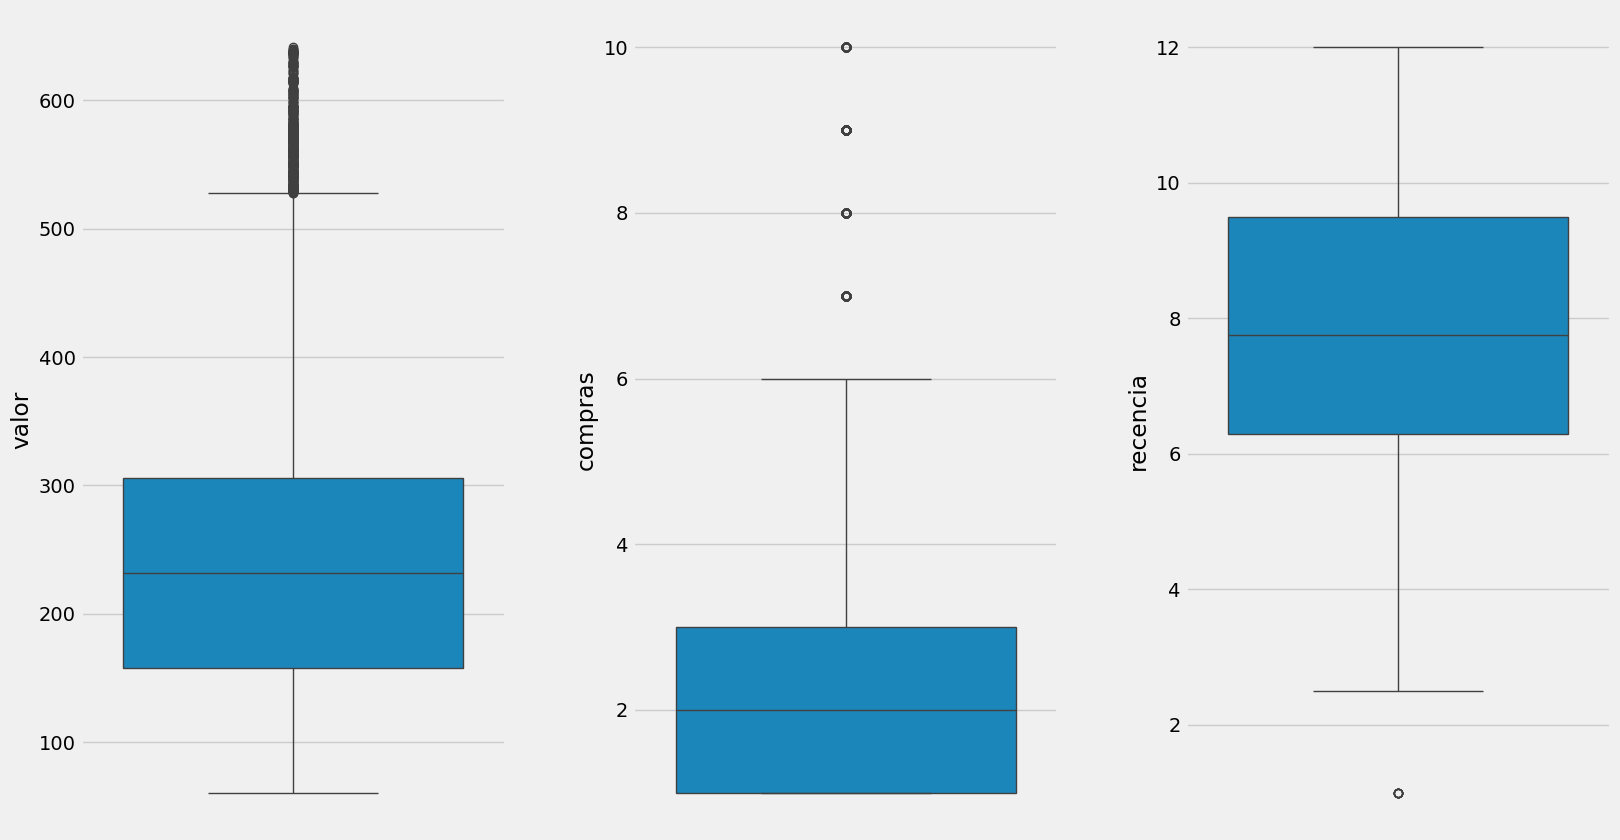

In [509]:
# Análise exploratória dos dados usando o gráfico Box Plot
features = var_num
fig,axs=plt.subplots(nrows=1, ncols=3, figsize=(18,10))
for col, ax in zip(features[0:], axs.ravel()):
    x=dados.loc[:, col]
    sns.boxplot(x, ax=ax, orient='V')
    plt.subplots_adjust(top=0.90,bottom=0.08, left=0.10,right=0.95,hspace=0.25,wspace=0.3)

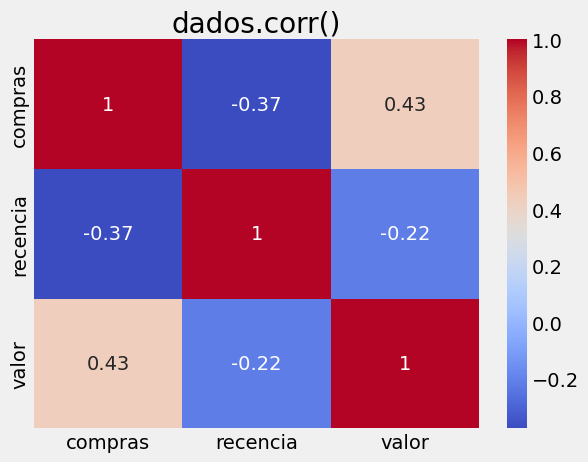

In [510]:
sns.heatmap(dados.corr(),cmap='coolwarm',annot=True)
plt.title('dados.corr()');

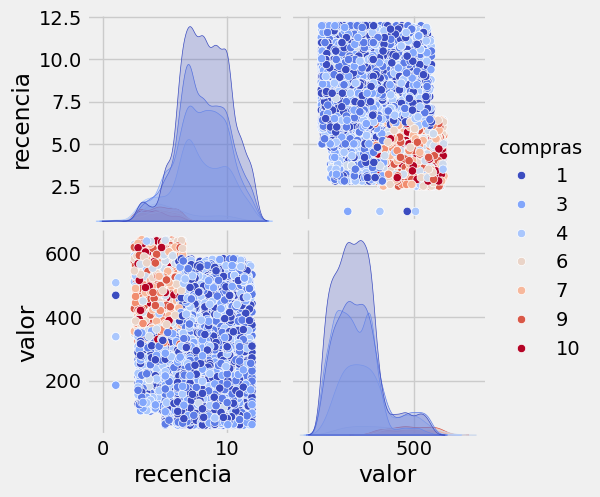

In [511]:
sns.pairplot(dados,hue='compras',palette='coolwarm');

### Normalizar os dados

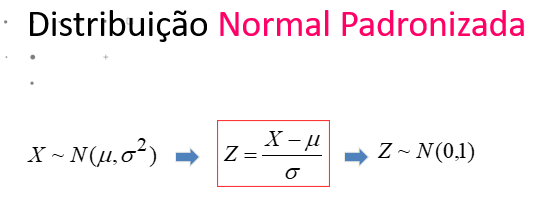




In [513]:
from sklearn.preprocessing import StandardScaler

In [514]:
# padronizar a variável para Normal com média igual a zero e desvio padrão igual a 1
scaler = StandardScaler()

cols = dados.columns

dados_padrao= scaler.fit_transform(dados)

dados_padrao = pd.DataFrame(dados_padrao, columns=[cols])




In [515]:
print(dados_padrao)

       compras  recencia     valor
0     0.780795 -1.271152 -0.620409
1    -0.322200  1.489455 -0.620409
2     0.780795 -1.361663 -0.740726
3    -0.873698  1.127408 -0.733048
4     0.229298  0.539082 -0.618510
...        ...       ...       ...
9873  0.229298  1.942013 -1.484708
9874  0.229298  1.625222 -0.131941
9875 -0.873698  1.036896  0.440274
9876  3.538284 -1.180640  2.092645
9877 -0.322200  1.489455  0.443203

[9878 rows x 3 columns]


In [516]:
pd.DataFrame(dados_padrao).describe().round(2)

,compras,recencia,valor
count,9878.00,9878.00,9878.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.87,-3.04,-1.50
25%,-0.87,-0.64,-0.73
50%,-0.32,0.02,-0.15
75%,0.23,0.81,0.44
max,4.09,1.94,3.09


### Análise de cluster

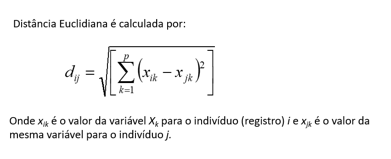

#### https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
#### Elbow method (clustering)
#### Encontrar o número de clusters


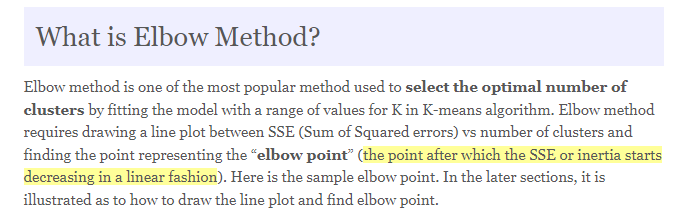

In [520]:
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# Elbow method (clustering)
# Encontrar o número de clusters

kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

sse = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(dados_padrao)
    sse.append(kmeans.inertia_)

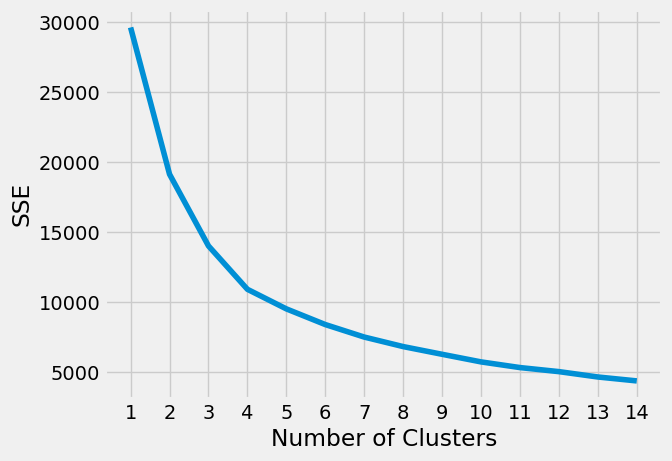

In [521]:
# Gráfico Sum of Squared errors vs number of clusters
plt.style.use("fivethirtyeight")
plt.plot(range(1, 15), sse)
plt.xticks(range(1, 15))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [522]:
# Hiperparâmetro do KMeans é o número de cluster (n_clusters)
model = KMeans(n_clusters = 6 , random_state=42)
clusters = model.fit_predict(dados_padrao)
Counter(clusters.tolist())

Counter({5: 2578, 0: 2061, 4: 1998, 2: 1698, 1: 826, 3: 717})

In [523]:
# Quantidade de observações em cada cluster
Counter(clusters.tolist())

Counter({5: 2578, 0: 2061, 4: 1998, 2: 1698, 1: 826, 3: 717})

In [524]:
# Centro do Cluster
model.cluster_centers_

array([[-0.22324084,  0.83275106, -0.90256294],
       [-0.15842207,  0.19626206,  1.79077778],
       [ 0.36523009, -1.00715932, -0.05023779],
       [ 2.7214212 , -1.48089393,  1.84657488],
       [-0.20896596,  0.9502126 ,  0.20132787],
       [-0.60757566, -0.38552055, -0.48709892]])

In [525]:
# Classificar o cliente em um dos cluster
# 1) calcular a distância euclidiana para cada cluster utilizando o centro de cada cluster
distance = model.fit_transform(dados_padrao)
distance

array([[2.3482134 , 2.9747698 , 0.75331395, 3.14579583, 2.56697072,
        1.65217678],
       [0.72156993, 2.74098395, 2.65155366, 4.91656507, 0.98937141,
        1.90124762],
       [2.41862249, 3.11733386, 0.88042093, 3.23641293, 2.68549116,
        1.71602892],
       ...,
       [1.50598202, 1.74417445, 2.44002207, 4.60888592, 0.71167273,
        1.71875295],
       [5.21287694, 3.95633908, 3.83279468, 0.90441577, 4.70738752,
        4.94726673],
       [1.50071281, 1.87486731, 2.63611937, 4.47839854, 0.60175374,
        2.11244714]])

In [526]:
# 2) o cluster do cliente será aquele com a menor distância calculada em 1)
labels = model.labels_
labels

array([2, 0, 2, ..., 4, 3, 4], dtype=int32)

In [527]:
dados_padrao['Cluster_Id'] = labels
dados_padrao.head(54)

,compras,recencia,valor,Cluster_Id
0,0.780795,-1.271152,-0.620409,2
1,-0.322200,1.489455,-0.620409,0
2,0.780795,-1.361663,-0.740726,2
3,-0.873698,1.127408,-0.733048,0
4,0.229298,0.539082,-0.618510,0
5,-0.873698,1.942013,0.478032,4
6,-0.873698,1.172664,-0.688800,0
7,-0.322200,0.810617,1.103043,4
8,-0.873698,1.896757,1.470562,4
9,0.229298,-1.497431,0.064207,2


In [528]:
dados_padrao[['Cluster_Id']].value_counts()/len(dados_padrao)*100

(Cluster_Id,)
5                26.098400
0                20.864547
4                20.226767
2                17.189715
1                 8.362017
3                 7.258554
Name: count, dtype: float64

In [529]:
# Hiperparâmetro do KMeans é o número de cluster (n_clusters)
clustersx = model.fit_predict(dados_padrao)

In [530]:
# Quantidade de observações em cada cluster
Counter(clustersx.tolist())

Counter({1: 2578, 5: 2061, 3: 1998, 4: 1698, 0: 826, 2: 717})

In [531]:
# Centro do Cluster
model.cluster_centers_

array([[-1.59288021e-01,  1.95471738e-01,  1.78962798e+00,
         1.00000000e+00],
       [-6.06078188e-01, -3.88478502e-01, -4.88846635e-01,
         5.00000000e+00],
       [ 2.72142120e+00, -1.48089393e+00,  1.84657488e+00,
         3.00000000e+00],
       [-2.08753954e-01,  9.49657492e-01,  2.00079971e-01,
         4.00000000e+00],
       [ 3.66684794e-01, -1.00647968e+00, -4.63067652e-02,
         2.00000000e+00],
       [-2.24530765e-01,  8.31356477e-01, -9.03984071e-01,
         2.66453526e-15]])

###  ==>Através do Centroide de cada cluster vc pode fazer um perfil médio de cada cluster formado

In [533]:
dados['clusterx'] = model.predict(dados_padrao)
dados.head()


,compras,recencia,valor,clusterx
0,4,4.9,172.37,4
1,2,11.0,172.37,5
2,4,4.7,157.17,4
3,1,10.2,158.14,5
4,3,8.9,172.61,5


In [534]:
dados[['clusterx']].value_counts()/len(dados)*100
 

clusterx
1           26.098400
5           20.864547
3           20.226767
4           17.189715
0            8.362017
2            7.258554
Name: count, dtype: float64

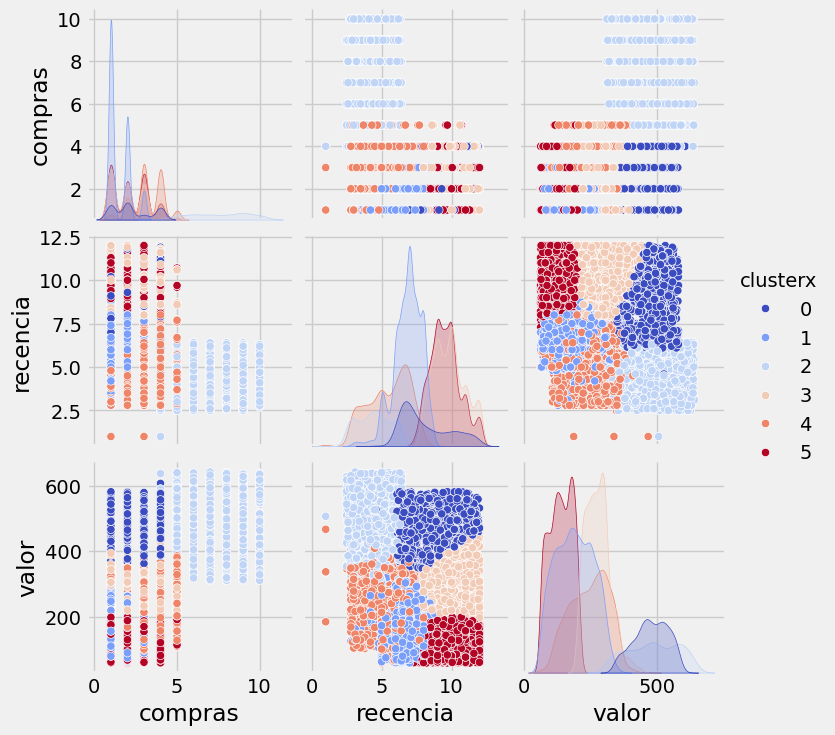

In [535]:
# Caracterização dos clusters
sns.pairplot(dados,hue='clusterx',palette='coolwarm')

In [536]:
dados.groupby(dados['clusterx'])['valor'].mean().reset_index()

,clusterx,valor
0,0,476.838705
1,1,188.990780
2,2,484.033013
3,3,276.025365
4,4,244.898439
5,5,136.544968


In [537]:
dados.groupby(dados['clusterx'])['recencia'].mean().reset_index()

,clusterx,recencia
0,0,8.140738
1,1,6.850407
2,2,4.436541
3,3,9.807232
4,4,5.484835
5,5,9.545827


In [538]:
dados.groupby(dados['clusterx'])['compras'].mean().reset_index()

,clusterx,compras
0,0,2.295400
1,1,1.485260
2,2,7.518828
3,3,2.205706
4,4,3.249117
5,5,2.177098


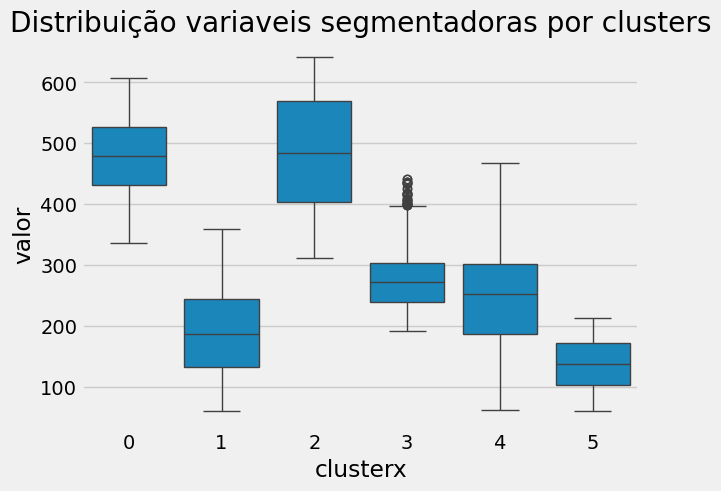

In [539]:
 # Variáveis segmentadoras  com a variável clusters
import matplotlib.pyplot as plt  
sns.boxplot(x='clusterx', y='valor', data=dados)
plt.title('Distribuição variaveis segmentadoras por clusters')
plt.show()

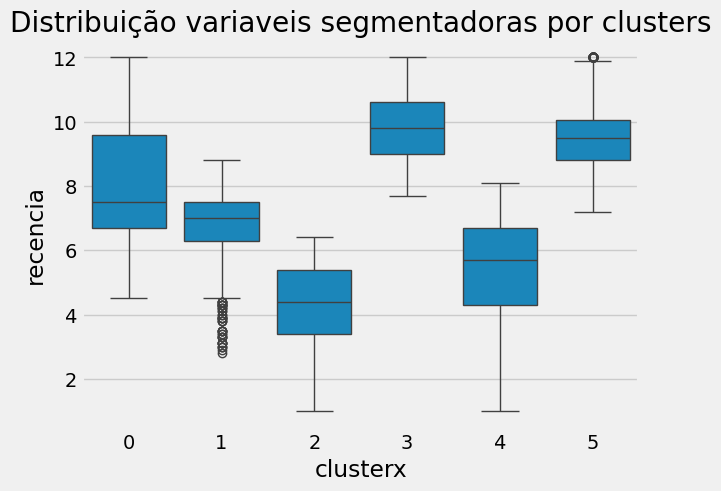

In [540]:
 # Variáveis segmentadoras  com a variável clusters
 
sns.boxplot(x='clusterx', y='recencia', data=dados)
plt.title('Distribuição variaveis segmentadoras por clusters')
plt.show()

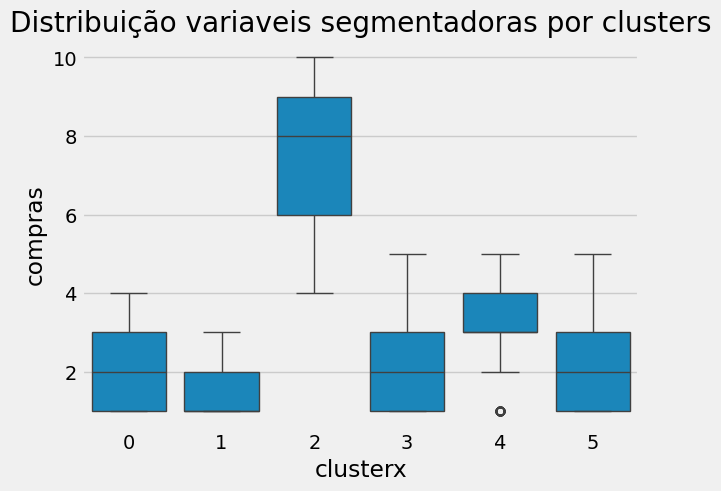

In [541]:
# Variáveis segmentadoras  com a variável clusters
 
sns.boxplot(x='clusterx', y='compras', data=dados)
plt.title('Distribuição variaveis segmentadoras por clusters')
plt.show()